In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
print(os.listdir())

file_path = "/content/Combined12.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

['.config', 'Combined12.csv', 'sample_data']
Shape: (533312, 8)


,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
0,971.5,0.25,9.0,7.0,10.7,0.0,0,0
1,972.3,0.97,10.5,6.7,13.5,0.0,0,0
2,972.4,0.74,6.5,3.9,9.1,0.0,0,0
3,973.2,0.15,5.1,3.7,7.7,0.0,0,0
4,975.7,0.12,5.2,2.6,8.3,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533312 entries, 0 to 533311
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Pressure          533312 non-null  float64
 1   global_radiation  533312 non-null  float64
 2   temp_mean(c)      533312 non-null  float64
 3   temp_min(c)       533312 non-null  float64
 4   temp_max(c)       533312 non-null  float64
 5   Wind_Speed        533312 non-null  float64
 6   Wind_Bearing      533312 non-null  int64  
 7   normalized_label  533312 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 32.6 MB


In [4]:
df.describe()

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
count,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000,533312.000000
mean,1011.436192,1.310346,12.646057,8.648474,16.871960,11.885974,192.501742,0.906152
std,3.241187,0.897191,6.519240,5.867740,7.692881,7.677086,101.984936,0.992549
min,971.500000,0.030000,-11.100000,-16.000000,-8.500000,0.000000,0.000000,0.000000
25%,1009.800000,0.510000,7.800000,4.500000,11.100000,6.410000,130.000000,0.000000
50%,1012.300000,1.160000,13.200000,9.400000,17.200000,11.040000,190.000000,1.000000
75%,1013.900000,2.010000,17.500000,13.300000,22.400000,15.620000,288.000000,2.000000
max,1015.000000,3.600000,28.600000,22.000000,37.000000,47.530000,359.000000,3.000000


In [5]:
df.isnull().sum()

,0
Pressure,0
global_radiation,0
temp_mean(c),0
temp_min(c),0
temp_max(c),0
Wind_Speed,0
Wind_Bearing,0
normalized_label,0


In [6]:
df.corr(numeric_only=True)

,Pressure,global_radiation,temp_mean(c),temp_min(c),temp_max(c),Wind_Speed,Wind_Bearing,normalized_label
Pressure,1.000000,0.222521,0.186470,0.144988,0.200911,-0.172945,-0.014122,-0.047407
global_radiation,0.222521,1.000000,0.686738,0.516741,0.758164,-0.037833,-0.003065,0.241394
temp_mean(c),0.186470,0.686738,1.000000,0.950680,0.973557,-0.031018,-0.001821,0.105278
temp_min(c),0.144988,0.516741,0.950680,1.000000,0.882243,-0.023715,-0.001643,0.033793
temp_max(c),0.200911,0.758164,0.973557,0.882243,1.000000,-0.033746,-0.002010,0.144671
Wind_Speed,-0.172945,-0.037833,-0.031018,-0.023715,-0.033746,1.000000,0.177154,0.692630
Wind_Bearing,-0.014122,-0.003065,-0.001821,-0.001643,-0.002010,0.177154,1.000000,0.098975
normalized_label,-0.047407,0.241394,0.105278,0.033793,0.144671,0.692630,0.098975,1.000000


In [7]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"{col} has constant values")

    if (df[col] == 0).mean() > 0.7:
        print(f"{col} has too many zeros (possible issue)")

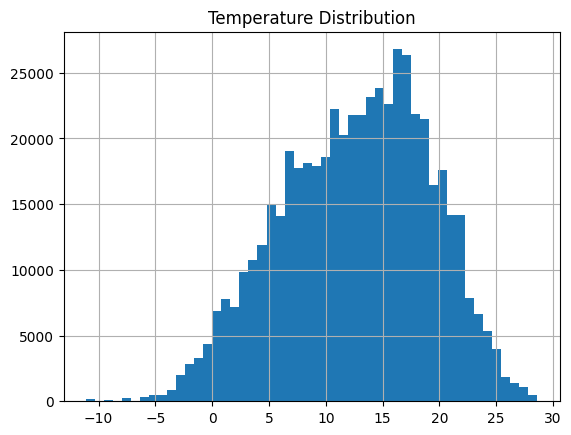

In [8]:
df['temp_mean(c)'].hist(bins=50)
plt.title("Temperature Distribution")
plt.show()

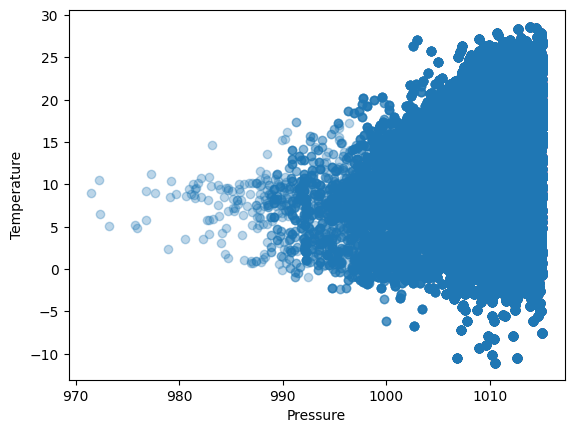

In [9]:
plt.scatter(df['Pressure'], df['temp_mean(c)'], alpha=0.3)
plt.xlabel("Pressure")
plt.ylabel("Temperature")
plt.show()

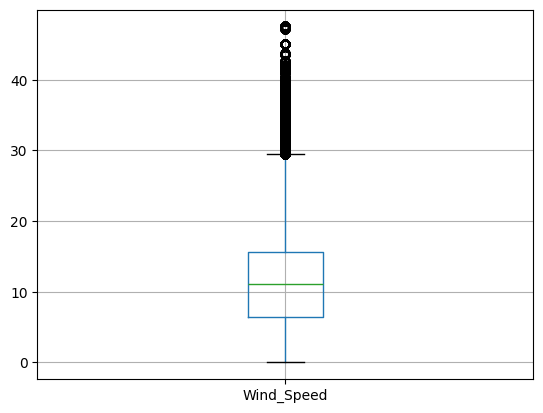

In [10]:
df.boxplot(column='Wind_Speed')
plt.show()

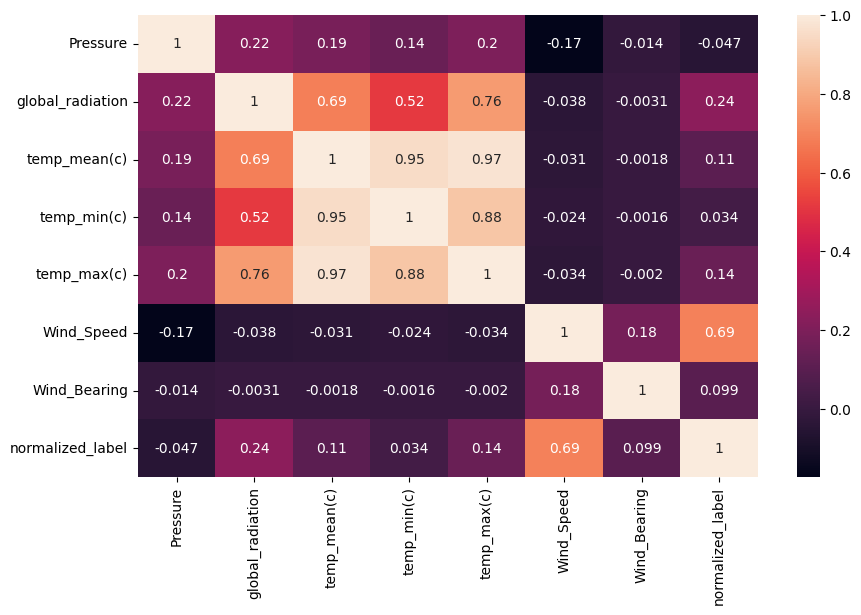

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [12]:
df.describe().to_csv("report.csv")
print("Report saved!")

Report saved!
